# โหลด CTSpine1K Dataset จาก Hugging Face

โหลดคู่ volume-label จาก https://huggingface.co/datasets/alexanderdann/CTSpine1K/tree/main/raw_data

- `raw_data/volumes/COLONOG/` → CT volumes
- `raw_data/labels/COLONOG/` → Segmentation masks

In [ ]:
# !pip install huggingface_hub nibabel

In [2]:
from huggingface_hub import HfApi, hf_hub_download
from pathlib import Path
import shutil
import os

# ============================================
# ตั้งค่าจำนวน cases ที่ต้องการโหลด
# ============================================
NUM_CASES = 20  # <-- เปลี่ยนจำนวนตรงนี้

# Output directories
DUMMY_DIR = Path("./dummy")
IMAGES_DIR = DUMMY_DIR / "images"
MASKS_DIR = DUMMY_DIR / "masks"

IMAGES_DIR.mkdir(parents=True, exist_ok=True)
MASKS_DIR.mkdir(parents=True, exist_ok=True)

print(f"จะโหลด {NUM_CASES} cases ไปที่:")
print(f"  Images: {IMAGES_DIR.absolute()}")
print(f"  Masks:  {MASKS_DIR.absolute()}")

จะโหลด 20 cases ไปที่:
  Images: e:\GitHub Project\Wat autoseg\autosegmentation-and-reconstruction\dummy\images
  Masks:  e:\GitHub Project\Wat autoseg\autosegmentation-and-reconstruction\dummy\masks


In [3]:
# ดึงรายชื่อไฟล์จาก HuggingFace
api = HfApi()
REPO_ID = "alexanderdann/CTSpine1K"

# ดึงรายชื่อไฟล์ทั้งหมดใน repo
all_files = api.list_repo_files(repo_id=REPO_ID, repo_type="dataset")

# แสดงโครงสร้างไฟล์
print("โครงสร้าง raw_data/:")
raw_data_paths = set()
for f in all_files:
    if f.startswith("raw_data/"):
        parts = f.split("/")
        if len(parts) >= 2:
            path = "/".join(parts[:3]) if len(parts) >= 3 else "/".join(parts[:2])
            raw_data_paths.add(path)

for d in sorted(raw_data_paths)[:20]:  # แสดง 20 รายการแรก
    print(f"  {d}")

# Filter เอาแค่ volumes และ labels (COLONOG)
volume_files = [f for f in all_files if f.startswith("raw_data/volumes/COLONOG/") and f.endswith(".nii.gz")]
seg_files = [f for f in all_files if f.startswith("raw_data/labels/COLONOG/") and f.endswith(".nii.gz")]

print(f"\nพบ {len(volume_files)} volumes, {len(seg_files)} labels")

โครงสร้าง raw_data/:
  raw_data/labels/COLONOG
  raw_data/labels/COVID-19
  raw_data/labels/HNSCC-3DCT-RT
  raw_data/labels/MSD-T10
  raw_data/volumes/COLONOG
  raw_data/volumes/COVID-19
  raw_data/volumes/HNSCC-3DCT-RT
  raw_data/volumes/MSD-T10

พบ 784 volumes, 784 labels


In [4]:
# จับคู่ volume กับ label
# Volume: raw_data/volumes/COLONOG/COLONOG-XXXX.nii.gz
# Label:  raw_data/labels/COLONOG/COLONOG-XXXX_seg.nii.gz

def extract_patient_id(filepath):
    """Extract patient ID from filename"""
    name = Path(filepath).name
    # Remove extensions and _seg suffix
    patient_id = name.replace(".nii.gz", "").replace("_seg", "")
    return patient_id

# สร้าง mapping
seg_dict = {}
for seg_path in seg_files:
    patient_id = extract_patient_id(seg_path)
    seg_dict[patient_id] = seg_path

# จับคู่
pairs = []
for vol_path in sorted(volume_files):
    patient_id = extract_patient_id(vol_path)
    if patient_id in seg_dict:
        pairs.append({
            "patient_id": patient_id,
            "volume_path": vol_path,
            "seg_path": seg_dict[patient_id]
        })

print(f"พบ {len(pairs)} คู่ volume-label")
print(f"\nตัวอย่าง 3 คู่แรก:")
for p in pairs[:3]:
    print(f"  {p['patient_id']}")
    print(f"    Vol: {p['volume_path']}")
    print(f"    Seg: {p['seg_path']}")

พบ 784 คู่ volume-label

ตัวอย่าง 3 คู่แรก:
  1.3.6.1.4.1.9328.50.4.0001
    Vol: raw_data/volumes/COLONOG/1.3.6.1.4.1.9328.50.4.0001.nii.gz
    Seg: raw_data/labels/COLONOG/1.3.6.1.4.1.9328.50.4.0001_seg.nii.gz
  1.3.6.1.4.1.9328.50.4.0002
    Vol: raw_data/volumes/COLONOG/1.3.6.1.4.1.9328.50.4.0002.nii.gz
    Seg: raw_data/labels/COLONOG/1.3.6.1.4.1.9328.50.4.0002_seg.nii.gz
  1.3.6.1.4.1.9328.50.4.0003
    Vol: raw_data/volumes/COLONOG/1.3.6.1.4.1.9328.50.4.0003.nii.gz
    Seg: raw_data/labels/COLONOG/1.3.6.1.4.1.9328.50.4.0003_seg.nii.gz


In [5]:
# เลือก cases ที่จะโหลด
selected_pairs = pairs[:NUM_CASES]

print(f"จะโหลด {len(selected_pairs)} cases:")
for i, p in enumerate(selected_pairs):
    print(f"  {i+1}. {p['patient_id']}")

จะโหลด 20 cases:
  1. 1.3.6.1.4.1.9328.50.4.0001
  2. 1.3.6.1.4.1.9328.50.4.0002
  3. 1.3.6.1.4.1.9328.50.4.0003
  4. 1.3.6.1.4.1.9328.50.4.0004
  5. 1.3.6.1.4.1.9328.50.4.0005
  6. 1.3.6.1.4.1.9328.50.4.0006
  7. 1.3.6.1.4.1.9328.50.4.0007
  8. 1.3.6.1.4.1.9328.50.4.0008
  9. 1.3.6.1.4.1.9328.50.4.0009
  10. 1.3.6.1.4.1.9328.50.4.0010
  11. 1.3.6.1.4.1.9328.50.4.0011
  12. 1.3.6.1.4.1.9328.50.4.0012
  13. 1.3.6.1.4.1.9328.50.4.0013
  14. 1.3.6.1.4.1.9328.50.4.0014
  15. 1.3.6.1.4.1.9328.50.4.0015
  16. 1.3.6.1.4.1.9328.50.4.0016
  17. 1.3.6.1.4.1.9328.50.4.0017
  18. 1.3.6.1.4.1.9328.50.4.0018
  19. 1.3.6.1.4.1.9328.50.4.0019
  20. 1.3.6.1.4.1.9328.50.4.0020


In [ ]:
# ดาวน์โหลดและ copy ไปยัง dummy folder
def download_pair(pair, images_dir, masks_dir):
    """Download volume and segmentation pair from HuggingFace"""
    patient_id = pair["patient_id"]
    
    # ตรวจสอบว่ามีไฟล์อยู่แล้วหรือไม่
    image_dest = images_dir / f"{patient_id}.nii.gz"
    mask_dest = masks_dir / f"{patient_id}.nii.gz"
    
    if image_dest.exists() and mask_dest.exists():
        return "skipped"
    
    try:
        # Download volume
        vol_local = hf_hub_download(
            repo_id=REPO_ID,
            repo_type="dataset",
            filename=pair["volume_path"],
            local_dir="./data/hf_cache"
        )
        shutil.copy2(vol_local, image_dest)
        
        # Download segmentation
        seg_local = hf_hub_download(
            repo_id=REPO_ID,
            repo_type="dataset",
            filename=pair["seg_path"],
            local_dir="./data/hf_cache"
        )
        shutil.copy2(seg_local, mask_dest)
        
        return "downloaded"
    except Exception as e:
        print(f"  ❌ Error: {e}")
        return "error"

# ดาวน์โหลด
print(f"กำลังดาวน์โหลด {len(selected_pairs)} cases...\n")

downloaded = 0
skipped = 0
errors = 0

for i, pair in enumerate(selected_pairs):
    print(f"[{i+1}/{len(selected_pairs)}] {pair['patient_id']}...", end=" ")
    result = download_pair(pair, IMAGES_DIR, MASKS_DIR)
    
    if result == "downloaded":
        print("✓ Downloaded")
        downloaded += 1
    elif result == "skipped":
        print("⏭ Already exists")
        skipped += 1
    else:
        errors += 1

print(f"\n✅ Done!")
print(f"   Downloaded: {downloaded}")
print(f"   Skipped: {skipped}")
print(f"   Errors: {errors}")

In [7]:
# ตรวจสอบไฟล์ที่โหลดมา
print("📁 dummy/images/")
images = sorted(IMAGES_DIR.glob("*.nii.gz"))
for img in images[:10]:  # แสดง 10 ไฟล์แรก
    print(f"   {img.name}")
if len(images) > 10:
    print(f"   ... และอีก {len(images)-10} ไฟล์")

print(f"\n📁 dummy/masks/")
masks = sorted(MASKS_DIR.glob("*.nii.gz"))
for msk in masks[:10]:
    print(f"   {msk.name}")
if len(masks) > 10:
    print(f"   ... และอีก {len(masks)-10} ไฟล์")

print(f"\n📊 Summary: {len(images)} images, {len(masks)} masks")

📁 dummy/images/
   1.3.6.1.4.1.9328.50.4.0001.nii.gz
   1.3.6.1.4.1.9328.50.4.0002.nii.gz
   1.3.6.1.4.1.9328.50.4.0003.nii.gz
   1.3.6.1.4.1.9328.50.4.0004.nii.gz
   1.3.6.1.4.1.9328.50.4.0005.nii.gz
   1.3.6.1.4.1.9328.50.4.0006.nii.gz
   1.3.6.1.4.1.9328.50.4.0007.nii.gz
   1.3.6.1.4.1.9328.50.4.0008.nii.gz
   1.3.6.1.4.1.9328.50.4.0009.nii.gz
   1.3.6.1.4.1.9328.50.4.0010.nii.gz
   ... และอีก 10 ไฟล์

📁 dummy/masks/
   1.3.6.1.4.1.9328.50.4.0001.nii.gz
   1.3.6.1.4.1.9328.50.4.0002.nii.gz
   1.3.6.1.4.1.9328.50.4.0003.nii.gz
   1.3.6.1.4.1.9328.50.4.0004.nii.gz
   1.3.6.1.4.1.9328.50.4.0005.nii.gz
   1.3.6.1.4.1.9328.50.4.0006.nii.gz
   1.3.6.1.4.1.9328.50.4.0007.nii.gz
   1.3.6.1.4.1.9328.50.4.0008.nii.gz
   1.3.6.1.4.1.9328.50.4.0009.nii.gz
   1.3.6.1.4.1.9328.50.4.0010.nii.gz
   ... และอีก 10 ไฟล์

📊 Summary: 20 images, 20 masks


## ทดสอบดูข้อมูลที่โหลดมา

Loading: 1.3.6.1.4.1.9328.50.4.0001.nii.gz
Volume shape: (512, 512, 604)
Mask shape: (512, 512, 604)
Volume range: [-1024.0, 3071.0] HU
Unique labels: [ 0. 14. 15. 16. 17. 18. 19. 20. 21. 22. 23. 24.]


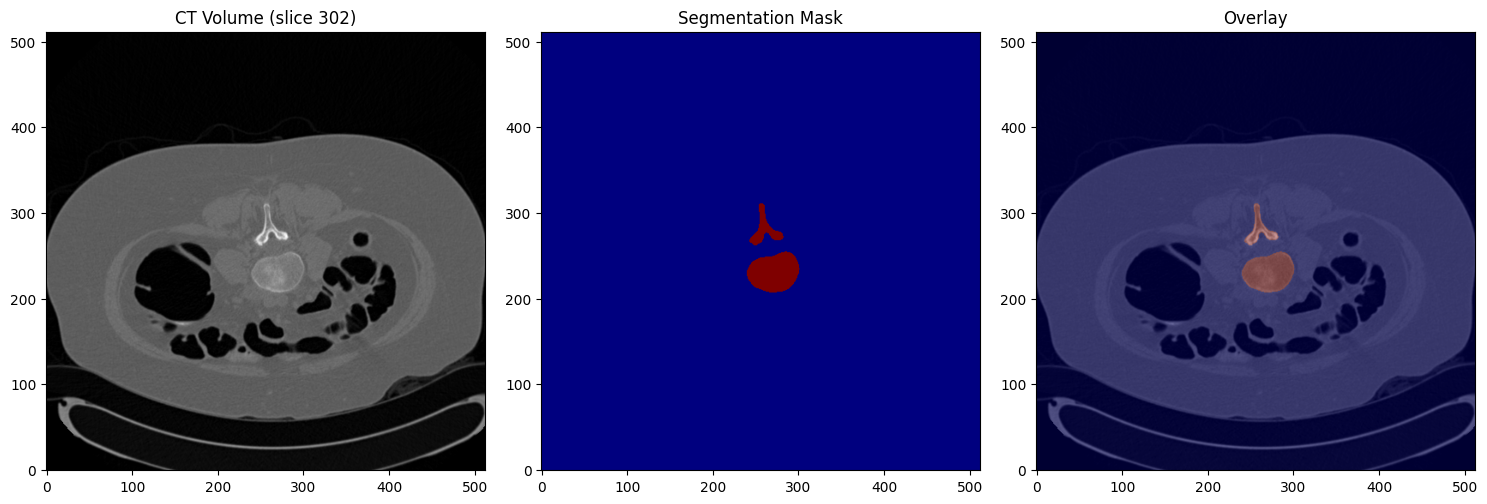

In [8]:
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt

# โหลดและแสดงตัวอย่าง
if len(images) > 0:
    # โหลดไฟล์แรก
    img_path = images[0]
    mask_path = MASKS_DIR / img_path.name
    
    print(f"Loading: {img_path.name}")
    
    volume = nib.load(str(img_path)).get_fdata()
    mask = nib.load(str(mask_path)).get_fdata()
    
    print(f"Volume shape: {volume.shape}")
    print(f"Mask shape: {mask.shape}")
    print(f"Volume range: [{volume.min():.1f}, {volume.max():.1f}] HU")
    print(f"Unique labels: {np.unique(mask)}")
    
    # แสดง middle slice
    mid_slice = volume.shape[2] // 2
    
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    
    axes[0].imshow(volume[:, :, mid_slice].T, cmap='gray', origin='lower')
    axes[0].set_title(f'CT Volume (slice {mid_slice})')
    
    axes[1].imshow(mask[:, :, mid_slice].T, cmap='jet', origin='lower')
    axes[1].set_title('Segmentation Mask')
    
    axes[2].imshow(volume[:, :, mid_slice].T, cmap='gray', origin='lower')
    axes[2].imshow(mask[:, :, mid_slice].T, cmap='jet', alpha=0.4, origin='lower')
    axes[2].set_title('Overlay')
    
    plt.tight_layout()
    plt.show()
else:
    print("No files found. Run the download cell first.")